# 타이타닉 탑승객 정보 --> 생존 여부 예측 
kaggle

### 라이브러리 불러오기

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

### 데이터 가져오기 (Seaborn)

In [5]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape # 행이 891개, 열이 15개

(891, 15)

### 결측치 체크

In [7]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum() # 컬럼별로 결측치 수 파악
# deck 같이 터무니 없이 큰 결측치는 안쓰는게 낫겠죠...?

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 생존 비율

In [ ]:
df['survived'].value_counts() # 0이 사망이고, 1이 생존

survived
0    549
1    342
Name: count, dtype: int64

### feature(입력값)

In [10]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

### label (정답, target) --> 'survived'
label(target) + features --> 새로운 데이터프레임 df_model

In [12]:
df_model = df[features + ['survived']].copy()  # 그래도 최대한 안전하게 가는게 좋아요
df_model

,pclass,sex,age,sibsp,parch,fare,survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,0
887,1,female,19.0,0,0,30.0000,1
888,3,female,NaN,1,2,23.4500,0
889,1,male,26.0,0,0,30.0000,1


### 결측치 처리 - 177개나 되니까 삭제하는 것보단 .fillna()로 채울게요 --> 중간값 선택!

In [22]:
df_model['age'] = df_model['age'].fillna(df_model['age'].median())
df_model.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
survived    0
dtype: int64

### 문자 데이터(sex)를 숫자로 변환 --> 레이블 인코딩 --> 남:0, 여:1

In [25]:
df_model['sex'] = df_model['sex'].map({'male':0, 'female':1})
df_model.head()

,pclass,sex,age,sibsp,parch,fare,survived
0,3,NaN,22.0,1,0,7.2500,0
1,1,NaN,38.0,1,0,71.2833,1
2,3,NaN,26.0,0,0,7.9250,1
3,1,NaN,35.0,1,0,53.1000,1
4,3,NaN,35.0,0,0,8.0500,0


In [26]:
X = df_model[features]
y = df_model['survived']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 모델 학습

In [28]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [29]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred = model.predict(X_test)

In [31]:
accuracy_score(y_test, y_pred)

0.6033519553072626

### 분류 레포트

In [32]:
classification_report(y_test, y_pred, target_names=['사망', '생존'])

'              precision    recall  f1-score   support\n\n          사망       0.69      0.65      0.67       110\n          생존       0.49      0.52      0.50        69\n\n    accuracy                           0.60       179\n   macro avg       0.59      0.59      0.59       179\nweighted avg       0.61      0.60      0.61       179\n'

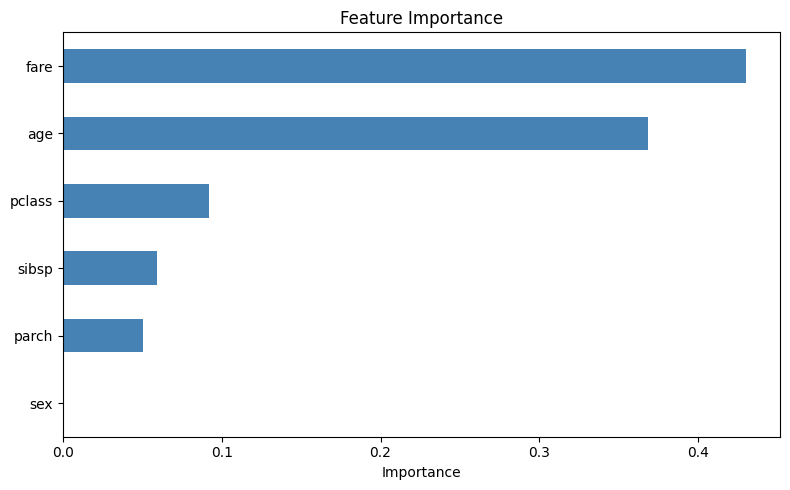

새 승객 예측:사망
생존 확률:2.0%


In [36]:
importance = pd.Series(
    model.feature_importances_,
    index=features,
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("titanic_importance.png")
plt.show()

new_passenger = pd.DataFrame({
    "pclass": [2],
    "sex": [1],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.5],
})

prediction = model.predict(new_passenger)
proba = model.predict_proba(new_passenger)

result = "생존" if prediction[0] == 1 else "사망"

print(f"새 승객 예측:{result}")
print(f"생존 확률:{proba[0][1]:.1%}")